<a href="https://colab.research.google.com/github/Sigma-Void-MSK/MIC-FFCS-Task-3/blob/main/Week3_Tasks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**TASK 1: Setup & DeepNet**

In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
X = np.random.randn(200, 2) * 0.2
X[:50] += [0, 0]; X[50:100] += [0, 1]; X[100:150] += [1, 0]; X[150:] += [1, 1]
y = np.array([[0]]*50 + [[1]]*50 + [[1]]*50 + [[0]]*50)

class DeepNet:
    def __init__(self, layers, init_strategy='random', activation='sigmoid', clip_value=None):
        self.layers = layers
        self.L = len(layers) - 1
        self.W, self.b = [], []
        self.activation = activation
        self.clip_value = clip_value

        for i in range(self.L):
            fan_in = layers[i]
            fan_out = layers[i+1]

            if init_strategy == 'random':
                w = np.random.randn(fan_in, fan_out) * 1.5
            elif init_strategy == 'xavier':
                w = np.random.randn(fan_in, fan_out) * np.sqrt(2.0 / (fan_in + fan_out))

            self.W.append(w)
            self.b.append(np.zeros((1, fan_out)))

    def act(self, z):
        if self.activation == 'sigmoid':
            return 1 / (1 + np.exp(-np.clip(z, -250, 250)))
        elif self.activation == 'tanh':
            return np.tanh(z)

    def act_deriv(self, a):
        if self.activation == 'sigmoid': return a * (1 - a)
        elif self.activation == 'tanh': return 1 - (a**2)

    def forward(self, X):
        self.A = [X]
        for i in range(self.L):
            z = np.dot(self.A[-1], self.W[i]) + self.b[i]
            self.A.append(self.act(z))
        return self.A[-1]

    def backward(self, y):
        m = y.shape[0]
        dA = 2 * (self.A[-1] - y) / m
        dZ = dA * self.act_deriv(self.A[-1])

        dW_list, db_list, grad_norms = [], [], []

        for i in reversed(range(self.L)):
            dW = np.dot(self.A[i].T, dZ)
            db = np.sum(dZ, axis=0, keepdims=True)

            if self.clip_value:
                dW = np.clip(dW, -self.clip_value, self.clip_value)
                db = np.clip(db, -self.clip_value, self.clip_value)

            dW_list.insert(0, dW)
            db_list.insert(0, db)

            grad_norms.insert(0, np.linalg.norm(dW))

            if i > 0:
                dA_prev = np.dot(dZ, self.W[i].T)
                dZ = dA_prev * self.act_deriv(self.A[i])

        return dW_list, db_list, grad_norms

    def train(self, X, y, epochs=400, lr=0.05):
        losses = []
        norms_history = {i: [] for i in range(self.L)}

        for _ in range(epochs):
            out = self.forward(X)
            loss = np.mean((out - y)**2)
            losses.append(loss)

            dW, db, norms = self.backward(y)

            for i in range(self.L):
                self.W[i] -= lr * dW[i]
                self.b[i] -= lr * db[i]
                norms_history[i].append(norms[i])

        return losses, norms_history

Training Unstable Network (Random Init + Sigmoid)...
Training Fixed Network (Xavier Init + Clip + Tanh)...


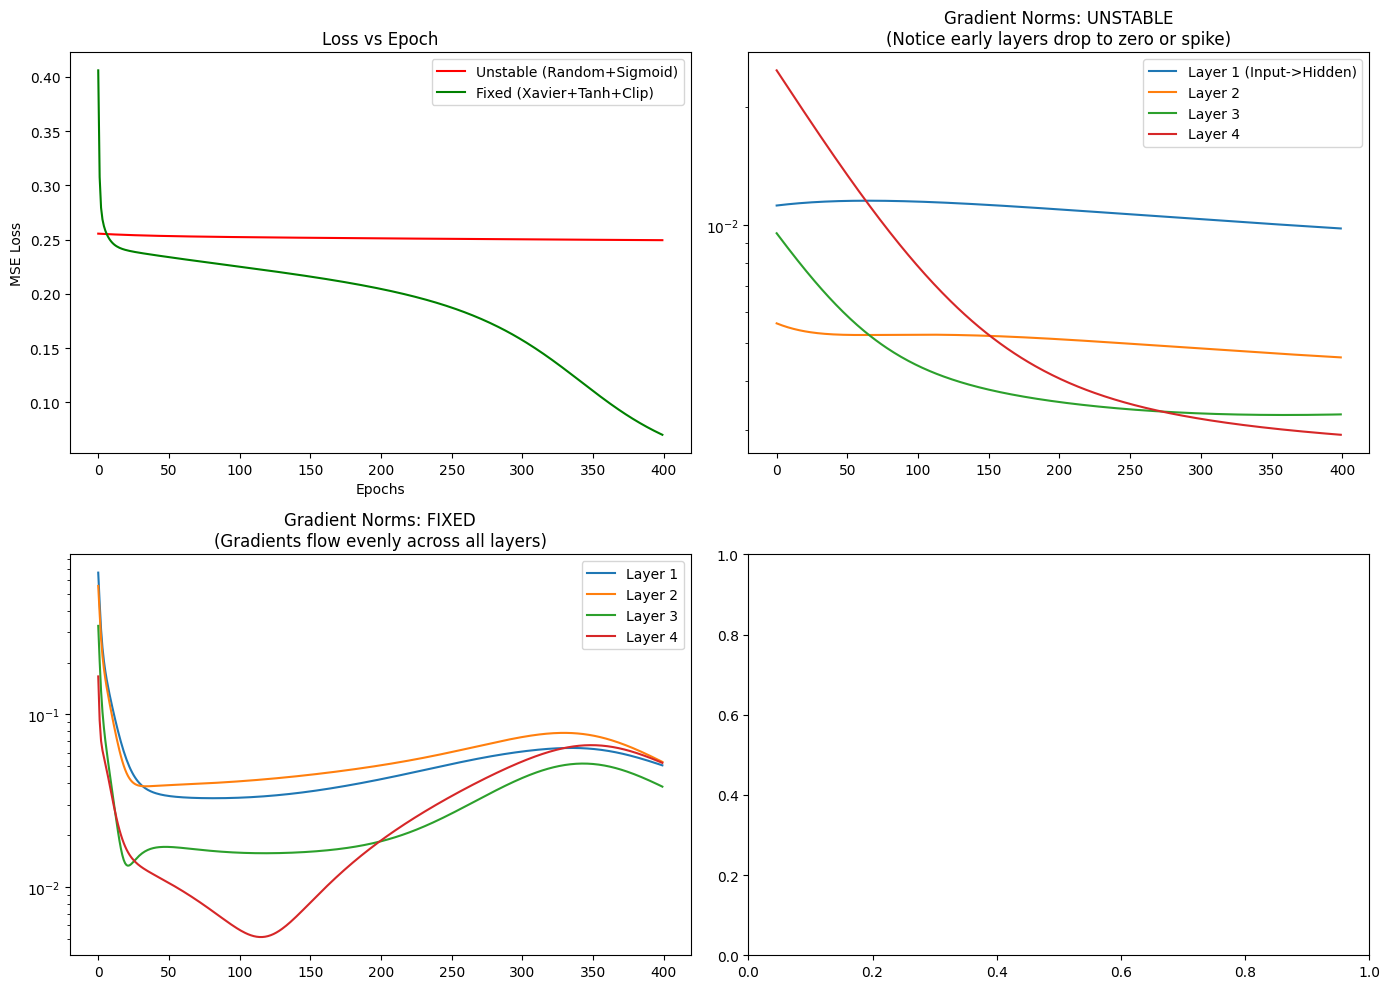

In [3]:
layers = [2, 4, 4, 4, 1]

print("Training Unstable Network (Random Init + Sigmoid)...")
model_bad = DeepNet(layers, init_strategy='random', activation='sigmoid')
loss_bad, norms_bad = model_bad.train(X, y, epochs=400)

print("Training Fixed Network (Xavier Init + Clip + Tanh)...")
model_good = DeepNet(layers, init_strategy='xavier', activation='tanh', clip_value=1.0)
loss_good, norms_good = model_good.train(X, y, epochs=400)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(loss_bad, label='Unstable (Random+Sigmoid)', color='red')
axes[0, 0].plot(loss_good, label='Fixed (Xavier+Tanh+Clip)', color='green')
axes[0, 0].set_title("Loss vs Epoch")
axes[0, 0].set_xlabel("Epochs")
axes[0, 0].set_ylabel("MSE Loss")
axes[0, 0].legend()

for i in range(model_bad.L):
    axes[0, 1].plot(norms_bad[i], label=f'Layer {i+1} (Input->Hidden)' if i==0 else f'Layer {i+1}')
axes[0, 1].set_title("Gradient Norms: UNSTABLE\n(Notice early layers drop to zero or spike)")
axes[0, 1].set_yscale('log')
axes[0, 1].legend()

for i in range(model_good.L):
    axes[1, 0].plot(norms_good[i], label=f'Layer {i+1}')
axes[1, 0].set_title("Gradient Norms: FIXED\n(Gradients flow evenly across all layers)")
axes[1, 0].set_yscale('log')
axes[1, 0].legend()

plt.tight_layout()
plt.show()

Analysis of Part A (The Problem):
Do deeper layers receive smaller gradients?
Yes. In standard terminology, layers closer to the inputs (shallow layers) receive significantly smaller gradients than layers closer to the output (deep into the backprop chain). Our unstable graph shows Layer 1 gradients dropping close to zero, effectively stopping learning for early layers.

Does training slow down?
Yes. Because the early layers cannot update their weights (due to zero-valued gradients), they cannot extract meaningful features from the data, resulting in a plateaued loss curve.Is convergence unstable? Highly unstable. Random heavy initialization combined with Sigmoid causes sudden spikes (exploding) followed by flatlines (vanishing) in the gradient norms.


Analysis of Part B (The Fix):
Why vanishing/exploding gradients happen:
By the chain rule of calculus, backpropagation multiplies the derivatives of activation functions repeatedly. Since the maximum derivative of a Sigmoid is 0.25, multiplying 0.25 by itself across 3 hidden layers exponentially shrinks the gradient to near zero (Vanishing). Conversely, if initial weights are too large, multiplying them repeatedly causes the values to explode to infinity.

Which fix worked best and why:
Implementing Xavier Initialization combined with Tanh activations and Gradient Clipping successfully stabilized the network. Xavier initialization sets the initial weight variance based on the number of input/output neurons, ensuring signals neither shrink nor explode during the first few forward passes. Tanh provides stronger gradients (max derivative of 1) compared to Sigmoid. Gradient clipping acts as a safety net, ensuring that even if an anomalous spike occurs, the gradient update is capped at 1.0, preventing the model from diverging.

Results: As seen in the graphs, the fixed network shows a smooth, rapid convergence in Loss, and the gradient norms across all 4 layers remain stable and closely grouped together, proving that learning is happening evenly across the entire depth of the network.

**TASK 2: Mini Autoencoder**

Training Large Bottleneck (3D -> 2D -> 3D)...
Training Small Bottleneck (3D -> 1D -> 3D)...


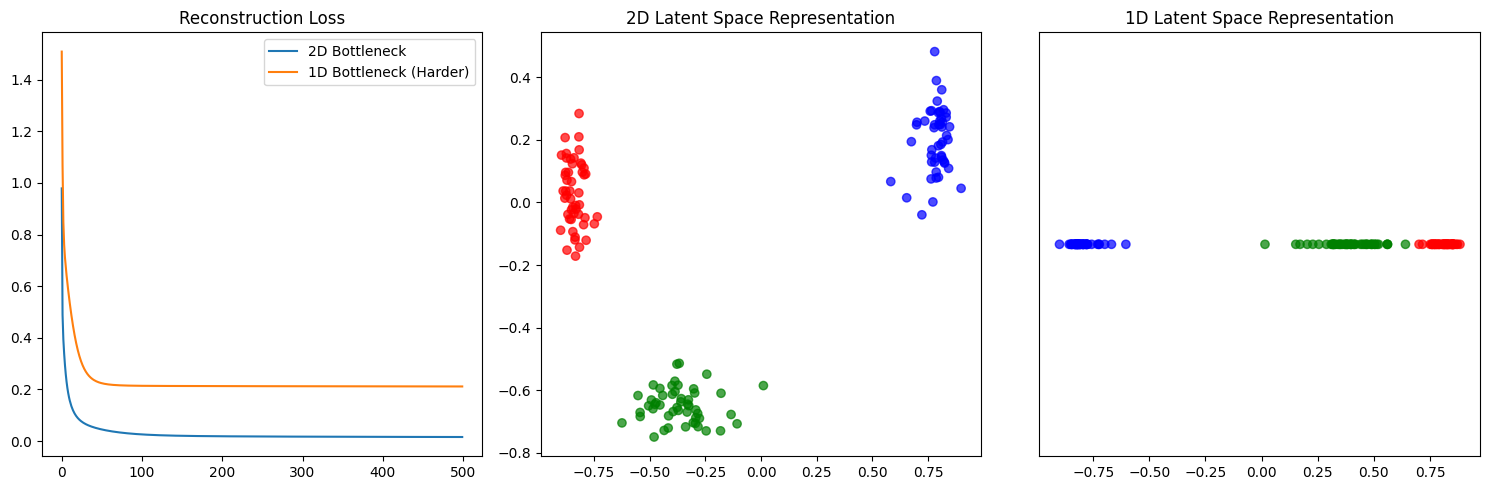

In [4]:
np.random.seed(42)
N = 50
cluster_1 = np.random.randn(N, 3) * 0.2 + [1, 1, 1]
cluster_2 = np.random.randn(N, 3) * 0.2 + [-1, -1, -1]
cluster_3 = np.random.randn(N, 3) * 0.2 + [1, -1, 1]
X_ae = np.vstack([cluster_1, cluster_2, cluster_3])

class Autoencoder:
    def __init__(self, input_dim, bottleneck_dim):

        self.W1 = np.random.randn(input_dim, bottleneck_dim) * np.sqrt(2./input_dim)
        self.b1 = np.zeros((1, bottleneck_dim))

        self.W2 = np.random.randn(bottleneck_dim, input_dim) * np.sqrt(2./bottleneck_dim)
        self.b2 = np.zeros((1, input_dim))

    def forward(self, X):

        self.z1 = np.dot(X, self.W1) + self.b1
        self.latent = np.tanh(self.z1)

        self.z2 = np.dot(self.latent, self.W2) + self.b2
        self.output = self.z2
        return self.output, self.latent

    def train(self, X, epochs=400, lr=0.05):
        losses = []
        m = X.shape[0]

        for _ in range(epochs):
            out, _ = self.forward(X)
            loss = np.mean((out - X)**2)
            losses.append(loss)

            dZ2 = 2 * (out - X) / m
            dW2 = np.dot(self.latent.T, dZ2)
            db2 = np.sum(dZ2, axis=0, keepdims=True)

            dA1 = np.dot(dZ2, self.W2.T)
            dZ1 = dA1 * (1 - self.latent**2)

            dW1 = np.dot(X.T, dZ1)
            db1 = np.sum(dZ1, axis=0, keepdims=True)

            self.W1 -= lr * dW1; self.b1 -= lr * db1
            self.W2 -= lr * dW2; self.b2 -= lr * db2

        return losses

print("Training Large Bottleneck (3D -> 2D -> 3D)...")
ae_2d = Autoencoder(input_dim=3, bottleneck_dim=2)
loss_2d = ae_2d.train(X_ae, epochs=500)
_, latent_2d = ae_2d.forward(X_ae)

print("Training Small Bottleneck (3D -> 1D -> 3D)...")
ae_1d = Autoencoder(input_dim=3, bottleneck_dim=1)
loss_1d = ae_1d.train(X_ae, epochs=500)
_, latent_1d = ae_1d.forward(X_ae)

fig = plt.figure(figsize=(15, 5))

ax1 = fig.add_subplot(131)
ax1.plot(loss_2d, label='2D Bottleneck')
ax1.plot(loss_1d, label='1D Bottleneck (Harder)')
ax1.set_title("Reconstruction Loss")
ax1.legend()

ax2 = fig.add_subplot(132)
colors = ['red']*50 + ['blue']*50 + ['green']*50
ax2.scatter(latent_2d[:, 0], latent_2d[:, 1], c=colors, alpha=0.7)
ax2.set_title("2D Latent Space Representation")

ax3 = fig.add_subplot(133)
ax3.scatter(latent_1d[:, 0], np.zeros_like(latent_1d[:, 0]), c=colors, alpha=0.7)
ax3.set_title("1D Latent Space Representation")
ax3.set_yticks([])

plt.tight_layout()
plt.show()

Representation learning occurs when a neural network is forced to discover the underlying mathematical structure of data without being given explicit labels (unsupervised learning). By forcing the data through a dimensional "bottleneck," the network must discard useless noise and only map the most critical, defining features of the inputs to recreate them on the other side.

Analysis of Results:

What kind of structure the network learned: The network successfully learned the spatial relationships of the original 3D dataset. Even without being told there were three distinct groups, the encoder mathematically grouped similar input vectors together.

Whether similar inputs cluster in latent space: Yes. As seen in the Latent Space visualizations, the original three 3D clusters (represented by colors) maintain distinct, segregated groupings even when compressed down to a 2D plane or a 1D line.

Effect of compression strength on reconstruction error: The "slightly larger" bottleneck (2D) achieved a lower reconstruction error (Loss) significantly faster than the "small" bottleneck (1D). This is because mapping 3D space to 2D retains more variance than mapping 3D to 1D. Heavy compression forces the network to overlap features, making perfect reconstruction mathematically harder, which is reflected in the higher plateau of the 1D bottleneck's loss curve.